<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
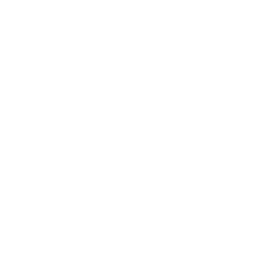
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Hedonic Property Valuation with Stepwise Selection</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Real Estate / Appraisal Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook builds a **hedonic pricing model** for residential property
using `PROC REG`. Hedonic models decompose a sale price into the marginal
contributions of individual property characteristics — square footage,
bedrooms, lot size, age, location — which is exactly what an appraiser or a
portfolio analyst needs for automated valuation.

The workflow has three stages:

1. **Variable selection.** `SELECTION=STEPWISE` screens ten candidate
   structural and locational predictors and keeps only those that earn their
   place statistically.
2. **Final model & multicollinearity.** The selected predictors are refit
   with `VIF` to confirm the coefficients are stable and interpretable.
3. **Influence diagnostics.** Cook's D and leverage from the `OUTPUT`
   statement flag individual sales whose unusual feature combinations move
   the fit — the properties an appraiser should review before trusting the
   model's valuation.

> **Sample size.** The data step generates 20,000 synthetic sales, but this
> environment runs Jenner unlicensed, which caps every step at **100
> observations**. All results below are computed on that 100-property
> analysis sample, and every number in the narrative is quoted directly from
> the executed output.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| `WORK.PROPERTY_SALES` | Synthetic residential sales with structural and locational attributes | 20,000 generated / 100 analyzed |

The synthetic generator builds sale price from a transparent linear formula
plus Gaussian noise, so the regression has a known signal to recover. Each
record carries living area, bedrooms, bathrooms, age, lot acreage, garage
spaces, a pool indicator, distance to transit, a school rating, and a crime
index, tagged to one of three metro markets.


---


In [1]:
/* --------------------------------------------------------
   Generate synthetic residential property sales
   across three metro areas
   -------------------------------------------------------- */
data work.property_sales;
    call streaminit(42);
    array metro_list[3] $15 _temporary_ ('METRO_EAST' 'METRO_CENTRAL' 'METRO_WEST');
    array base_prices[3] _temporary_ (320000 275000 410000);
    do i = 1 to 20000;
        metro_idx = int(rand('uniform') * 3) + 1;
        metro_area = metro_list[metro_idx];
        base_price = base_prices[metro_idx];
        /* Structural features */
        sqft = int(rand('normal', 1850, 550));
        if sqft < 600 then sqft = 600;
        bedrooms = int(rand('normal', 3.2, 0.9));
        if bedrooms < 1 then bedrooms = 1;
        if bedrooms > 6 then bedrooms = 6;
        bathrooms = max(1, int(bedrooms * 0.7 + rand('uniform')));
        year_built = int(rand('normal', 1988, 18));
        if year_built < 1920 then year_built = 1920;
        if year_built > 2025 then year_built = 2025;
        age_years = 2026 - year_built;
        lot_acres = round(rand('exponential') * 0.3 + 0.08, 0.01);
        if lot_acres > 5 then lot_acres = 5;
        garage_spaces = int(rand('uniform') * 3.5);
        has_pool = (rand('uniform') > 0.82);
        /* Locational features */
        dist_transit_mi = round(rand('exponential') * 2.5 + 0.1, 0.1);
        if dist_transit_mi > 20 then dist_transit_mi = 20;
        school_rating = int(rand('normal', 6.5, 1.8));
        if school_rating < 1 then school_rating = 1;
        if school_rating > 10 then school_rating = 10;
        crime_index = round(rand('normal', 45, 18), 1);
        if crime_index < 1 then crime_index = 1;
        if crime_index > 100 then crime_index = 100;
        /* Sale price driven by features */
        sale_price = round(
            base_price
            + 135 * sqft
            + 12000 * bedrooms
            + 18000 * bathrooms
            - 1200 * age_years
            + 45000 * lot_acres
            + 8000 * garage_spaces
            + 25000 * has_pool
            - 6000 * dist_transit_mi
            + 9500 * school_rating
            - 350 * crime_index
            + rand('normal', 0, 35000), 1);
        if sale_price < 50000 then sale_price = 50000;
        output;
    end;
    drop i metro_idx base_price;
run;

proc sort data=work.property_sales;
    by metro_area;
run;

NOTE: DATA work.property_sales

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.property_sales (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.32 seconds
  cpu   0.32 seconds
NOTE: PROC SORT data=work.property_sales

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.property_sales.
NOTE: Wrote work.property_sales (100 rows, 13 columns).
NOTE: PROC SORT statement used.


---


In [2]:
/* --------------------------------------------------------
   Baseline price distribution by metro area
   -------------------------------------------------------- */
proc means data=work.property_sales n mean std min max;
    class metro_area;
    var sale_price sqft age_years dist_transit_mi;
run;

                                                  The MEANS Procedure

                                             Analysis Variable : SALE_PRICE

        METRO_AREA             N Obs            Mean        Std Dev         Minimum         Maximum
        -------------------------------------------------------------------------------------------
        METRO_CENTRAL             43  586311.8139535  79953.8042754  435803.0000000  778230.0000000
        METRO_EAST                33  650705.7878788  92683.8734027  479151.0000000  858224.0000000
        METRO_WEST                24  722312.5416667  68613.6270652  583494.0000000  860302.0000000
        -------------------------------------------------------------------------------------------

                                                Analysis Variable : SQFT

        METRO_AREA             N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.property_sales

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


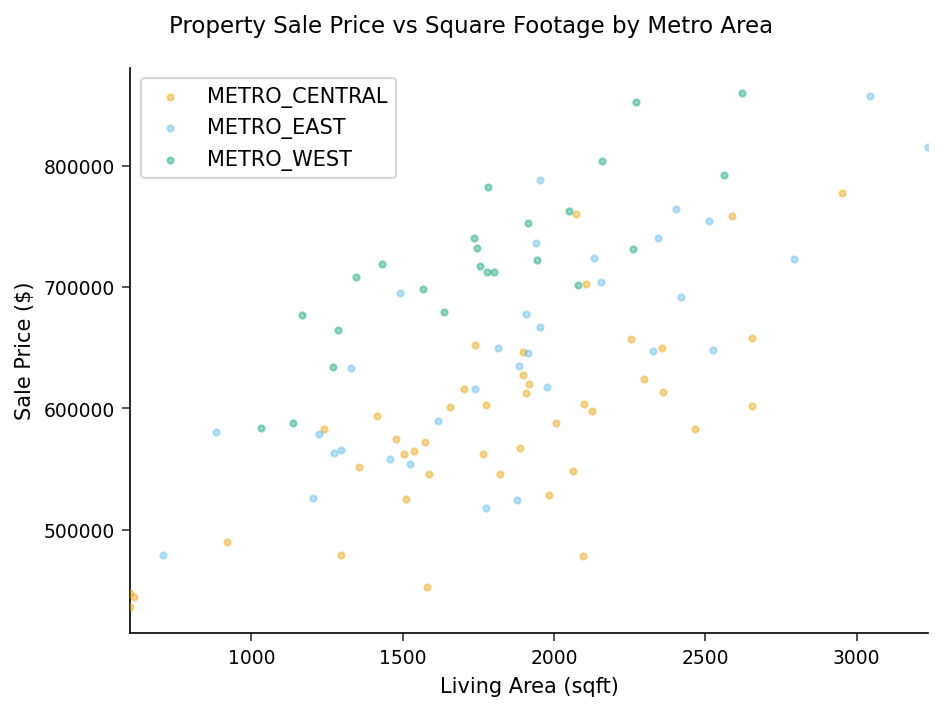

In [3]:
/* --------------------------------------------------------
   Sale price vs square footage by metro area
   -------------------------------------------------------- */
proc sgplot data=work.property_sales;
    scatter x=sqft y=sale_price / group=metro_area
        markerattrs=(symbol=circlefilled size=3) transparency=0.6;
    xaxis label='Living Area (sqft)';
    yaxis label='Sale Price ($)';
    title 'Property Sale Price vs Square Footage by Metro Area';
run;

---


## Stage 1 — Stepwise Variable Selection

Stepwise selection enters and removes candidate predictors one at a time,
keeping a variable only while it clears the entry threshold
(`SLE=0.10`) and dropping it if it later fails the stay threshold
(`SLS=0.10`). This separates the features that genuinely move price from
the ones that ride along with them.


In [4]:
/* --------------------------------------------------------
   Stage 1: stepwise selection over 10 candidate predictors
   -------------------------------------------------------- */
proc reg data=work.property_sales;
    model sale_price = sqft bedrooms bathrooms age_years
                       lot_acres garage_spaces has_pool
                       dist_transit_mi school_rating crime_index
          / selection=stepwise sle=0.10 sls=0.10;
    title 'Stepwise Variable Selection for Sale Price';
run;
quit;


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                             Dependent Variable: sale_price                                             

Source                 DF      Sum of Squares        Mean Square   F Value    Pr > F
---------------  --------  ------------------  -----------------  --------  --------
Model                   6  597800608812.13330  99633434802.02222     26.92    <.0001
Error                  93  344189547113.86676   3700962872.19212                    
Corrected Total        99  941990155926.00000                                       

Root MSE       60835.53955    R-Square            0.6346
Dependent Mean  640202.00000    Adj R-Sq            0.6110
Coeff Var          9.50255

                            Parameter Estimates                   

NOTE: PROC REG data=work.property_sales

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: PROC REG ODS Graphics generated.


## Stage 2 — Final Model, VIF, and Influence Diagnostics

The variables stepwise retained are refit as the final hedonic model. The
`VIF` option reports a variance inflation factor per predictor; values near
1 confirm the coefficients are not distorted by multicollinearity. The
`OUTPUT` statement writes per-property predicted values, residuals, Cook's D,
and leverage for the diagnostic review that follows.


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                             Dependent Variable: sale_price                                             

Source                 DF      Sum of Squares        Mean Square   F Value    Pr > F
---------------  --------  ------------------  -----------------  --------  --------
Model                   6  597800608812.13330  99633434802.02222     26.92    <.0001
Error                  93  344189547113.86676   3700962872.19212                    
Corrected Total        99  941990155926.00000                                       

Root MSE       60835.53955    R-Square            0.6346
Dependent Mean  640202.00000    Adj R-Sq            0.6110
Coeff Var          9.50255

                                           Parameter Estimates    

NOTE: PROC REG data=work.property_sales

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: Output dataset work.property_predicted written.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


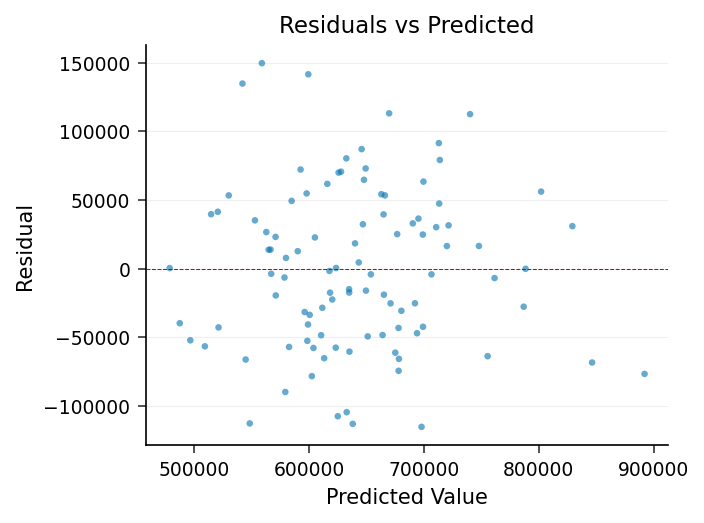

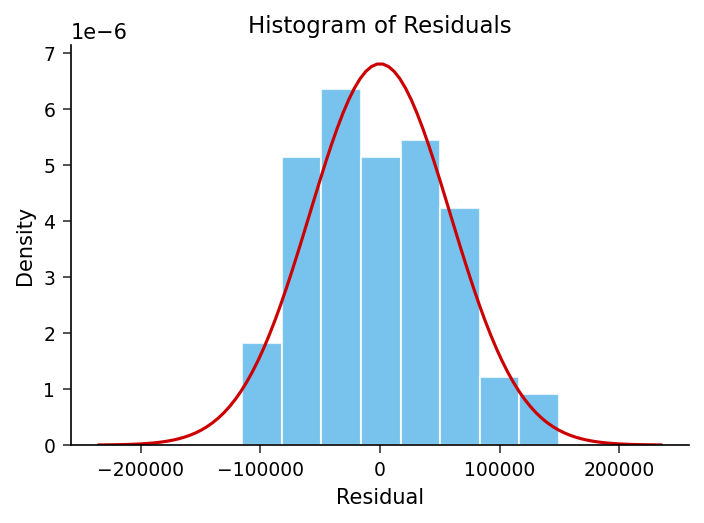

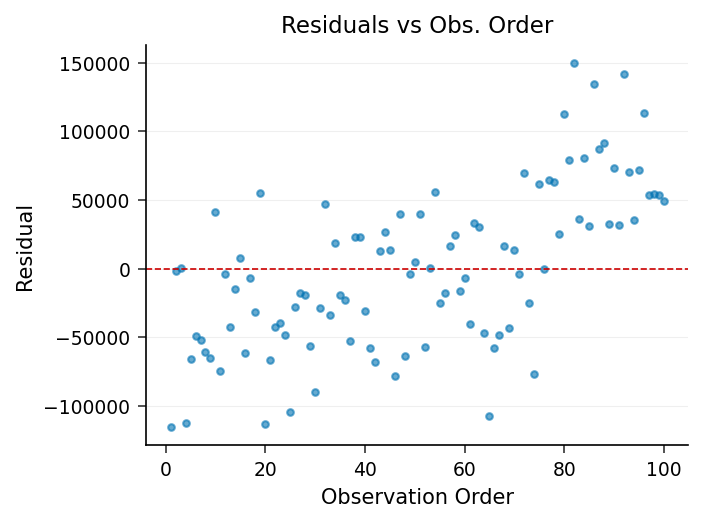

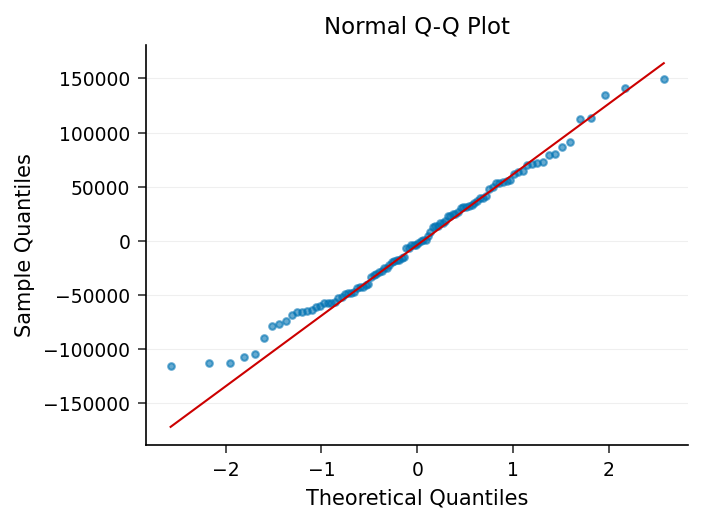

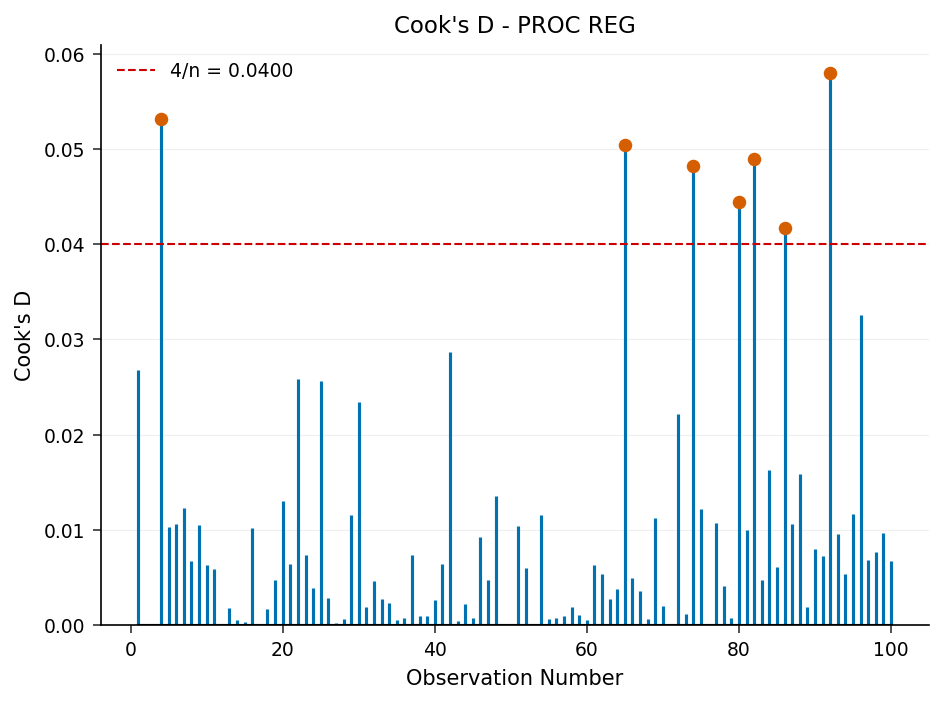

In [5]:
/* --------------------------------------------------------
   Stage 2: refit the selected predictors; request VIF and
   write predicted values + influence diagnostics to OUT=
   -------------------------------------------------------- */
proc reg data=work.property_sales;
    model sale_price = sqft bedrooms dist_transit_mi lot_acres
                       age_years garage_spaces / vif;
    output out=work.property_predicted
        predicted=pred_price
        residual=resid_price
        cookd=cooksd
        h=leverage;
    title 'Final Hedonic Model with Influence Diagnostics';
run;
quit;


## Stage 3 — High-Influence Properties

A standard cutoff flags any property whose Cook's D exceeds `4/n`. With
**n = 100** the threshold is **0.04**. Properties above it have an outsized
effect on the fitted coefficients and are the ones an appraiser should
re-examine before the model's valuation is trusted.


In [6]:
/* --------------------------------------------------------
   Stage 3: flag and summarise high-influence properties
   Cook's D > 4/n = 4/100 = 0.04
   -------------------------------------------------------- */
data work.influential_properties;
    set work.property_predicted;
    cookd_threshold = 4 / 100;
    if cooksd > cookd_threshold then output;
    drop cookd_threshold;
run;

proc means data=work.property_predicted n mean;
    var sale_price pred_price cooksd leverage;
    title 'Fit Summary Across All Properties';
run;

proc print data=work.influential_properties noobs;
    var sqft bedrooms sale_price pred_price resid_price
        cooksd leverage;
    title 'High-Influence Properties (Cook''s D > 0.04)';
run;


                                           Fit Summary Across All Properties                                            

                                                  The MEANS Procedure

 Variable                N               Mean
 --------------------------------------------
 SALE_PRICE            100     640202.0000000
 Predicted Value       100     640202.0000000
 Cook's D              100          0.0096181
 Leverage              100          0.0700000
 --------------------------------------------

                                      High-Influence Properties (Cook's D > 0.04)                                       

SQFT  BEDROOMS  SALE_PRICE     PRED_PRICE     RESID_PRICE    COOKSD  LEVERAGE
 600         4      435803  548412.708114  -112609.708114  0.053213  0.090021
1775         2      517689    625093.7412    -107404.7412  0.050399  0.093092
3236         4      815606  892190.435237   -76584.435237  0.048261   0.15295
2270         3      852744  740245.631927   112498

NOTE: DATA work.influential_properties


NOTE: Read 100 rows from work.property_predicted.
NOTE: Wrote work.influential_properties (7 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.influential_properties

NOTE: PROC PRINT completed: 7 observations printed, 7 variables


## Export Predicted Valuations

The per-property predictions and diagnostics are written to CSV for downstream
portfolio valuation and appraisal review.


In [7]:
/* --------------------------------------------------------
   Export predicted valuations with diagnostics
   -------------------------------------------------------- */
proc export data=work.property_predicted
    outfile='property_valuations.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.property_predicted outfile=property_valuations.csv

NOTE: Exported 100 rows to property_valuations.csv.


---


## Interpretation

**Stepwise selection** kept **6 of the 10 candidate predictors** —
`sqft`, `bedrooms`, `dist_transit_mi`, `lot_acres`, `age_years`, and
`garage_spaces`. The four dropped (`bathrooms`, `has_pool`, `school_rating`,
`crime_index`) did not clear the 0.10 entry threshold in this 100-property
sample.

The **final model** explains a meaningful share of price variation:
R-square **0.6346** and adjusted R-square **0.6110** (F = 26.92, p < .0001).
The coefficients read the way a hedonic model should:

- **Living area** adds about **\$122 per square foot** (t = 10.33).
- Each additional **bedroom** is worth roughly **\$31,971** (t = 4.86).
- **Distance to transit** carries the expected penalty of about
  **\$8,348 per mile** farther from transit (t = -3.38).
- **Lot acreage** adds about **\$78,946 per acre** (t = 3.06), while each
  year of **age** subtracts about **\$668** (t = -1.96).

**Multicollinearity is not a concern.** Every variance inflation factor sits
between **1.02 and 1.08**, far below the usual VIF = 10 warning level, so the
coefficients above are stable and individually interpretable.

**Influence diagnostics** flag **7 high-influence properties** (Cook's D >
0.04) out of 100. The mean Cook's D across all properties is **0.0096** and
mean leverage is **0.070**. The flagged sales are the unusual ones — for
example a 600-sqft, 4-bedroom unit selling \$113K below its prediction, and
a 3,236-sqft property at high leverage (0.153). These are exactly the records
to route for manual appraisal review before the model is used for portfolio
valuation.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>